# Multi-Compartment population demo

This notebook builds a tiny hand-written morphology, instantiates a `braincell.Cell` with `pop_size=(2, 2)`, injects different soma currents into the four cells, and plots their voltage traces.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import brainunit as u
import jax.numpy as jnp

os.environ.setdefault("JAX_PLATFORMS", "cpu")

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import braincell
from braincell import Branch, Morphology, Cell, CVPerBranch
import braincell.mech as mech
from braincell.filter import at

print("braincell version:", braincell.__version__)
print("repo_root:", repo_root)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


braincell version: 0.1.0
repo_root: /home/swl/braincell


In [2]:
# 1. Build a tiny soma+dendrite morphology by hand.
soma = Branch.from_lengths(
    lengths=[20.0] * u.um,
    radii=[10.0, 10.0] * u.um,
    type="soma",
)
dend = Branch.from_lengths(
    lengths=[120.0] * u.um,
    radii=[2.5, 1.5] * u.um,
    type="basal_dendrite",
)
morph = Morphology.from_root(soma, name="soma")
morph.soma.dend = dend

print("n_branches =", len(morph.branches))


n_branches = 2


In [3]:
# 2. Create a homogeneous 2x2 population of identical cells.
#    The four cells differ only through parameter values.
amp = u.Quantity(jnp.asarray([[0.00, 0.09], [0.06, 0.12]]), u.nA)

cell = Cell(
    morph,
    cv_policy=CVPerBranch(),
    pop_size=(2, 2),
    solver="staggered",
    V_init=-60.0 * u.mV,
)

# Add one voltage probe and one soma current clamp.
cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))
cell.place(
    at("soma", 0.5),
    mech.CurrentClamp(delay=0.5 * u.ms, durations=2.0 * u.ms, amplitudes=amp),
)

cell.init_state()
print("pop_size =", cell.pop_size)
print("n_cv =", cell.n_cv)
print("varshape =", cell.varshape)
print("V shape =", cell.V.value.shape)


pop_size = (2, 2)
n_cv = 2
varshape = (2, 2, 2)
V shape = (2, 2, 2)


In [4]:
# 3. Run the simulation and inspect trace shapes.
result = cell.run(dt=0.05 * u.ms, duration=4.0 * u.ms)
times_ms = result.time.to_decimal(u.ms)
trace = result.traces["v"]

print("trace shape =", trace.shape)
print("time shape =", result.time.shape)


trace shape = (80, 2, 2)
time shape = (80,)


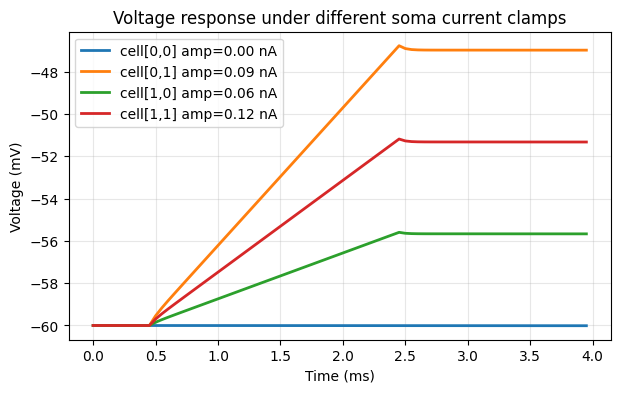

In [5]:
# 4. Plot the four voltage traces.
fig, ax = plt.subplots(figsize=(7, 4))
for i in range(cell.pop_size[0]):
    for j in range(cell.pop_size[1]):
        ax.plot(
            times_ms,
            trace[:, i, j].to_decimal(u.mV),
            label=f"cell[{i},{j}] amp={float(amp[i, j].to_decimal(u.nA)):.2f} nA",
            linewidth=2,
        )

ax.set_title("Voltage response under different soma current clamps")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (mV)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()
